In [2]:
from sentence_transformers import SentenceTransformer
from huggingface_hub import notebook_login

import pandas as pd

notebook_login()

In [3]:
model = SentenceTransformer("google/embeddinggemma-300m")
#model = SentenceTransformer("Qwen/Qwen3-Embedding-4B")

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

In [4]:
ads = pd.read_csv("jobs-no-noise.csv")

In [5]:
jobs_embeddings = model.encode_document(ads["Text"], prompt_name="Classification")

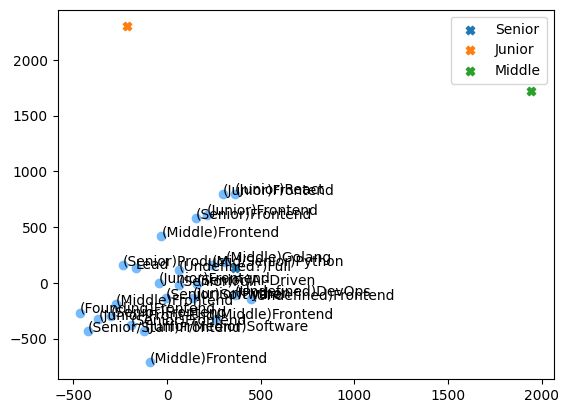

In [5]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

clusters = {"Senior": "A senior-level, lead, or principal job description. Characteristics: high autonomy, strategic decision-making, architectural oversight, and mentoring others. Involves solving ambiguous problems, owning end-to-end projects, and typically requires 5+ years of experience. Focuses on high-level impact and leadership.",
            "Junior": "An entry-level or associate job description. Characteristics: focus on learning and execution, requires regular supervision and guidance, involves performing clearly defined tasks, and typically requires 0 to 2 years of experience. Focuses on foundational skill development.",
            "Middle": "A mid-level or intermediate professional job description. Characteristics: operates as an independent individual contributor, manages moderate complexity with minimal supervision, collaborates across teams, and typically requires 3 to 5 years of experience. Focuses on proficiency and reliable delivery."}
clusters_keys = list(clusters.keys())

tsne = TSNE(n_components=2, perplexity=len(clusters) - 1, random_state=42, init='random', learning_rate=200)
vis_dims = tsne.fit_transform(jobs_embeddings)

names = ads["Job"].to_list()
i = 0

for x, y in vis_dims:
    plt.scatter(x, y, color='xkcd:sky blue')
    plt.annotate(names[i].split()[0], (x, y))
    i += 1

i = 0 
for x, y in tsne.fit_transform(np.array(
        [model.encode_query(cluster, prompt_name="Classification") for cluster in clusters.values()])):
    plt.scatter(x, y, marker="X", label=clusters_keys[i])
    i += 1

plt.legend()

In [6]:
# Query is a good job ad for user
job_ad = """The Role
We're looking for a Junior Frontend Developer to join our product team.

Requirements

1+ year of experience with JavaScript/TypeScript
Practical experience with React or similar modern frontend frameworks
Understanding of HTML, CSS, and responsive design principles
Familiarity with Git and version control workflows
Basic understanding of state management concepts
Ability to translate designs into working UI components
Experience with testing (unit tests, component testing)
Strong attention to code quality and detail
Good problem-solving skills and willingness to learn
English proficiency (B2 or higher)

"""

In [7]:
sts_embeddings = model.encode(ads["Text"], prompt_name="STS")

In [8]:
query_embeddings = model.encode_query(job_ad, prompt_name="STS")

ads["STS_Results"] = model.similarity(query_embeddings, sts_embeddings)[0].tolist()

print(ads.sort_values("STS_Results", ascending=False)[["Job", "STS_Results"]])

                                                  Job  STS_Results
10    (Junior)Frontend Developer (E-Commerce Startup)     0.843872
12                         (Middle)Frontend Developer     0.838292
18      (Middle)Frontend Engineer (Miners/Blockchain)     0.816208
0                   (Junior)Frontend Developer (Web3)     0.810233
13                            (Junior)React Developer     0.802315
11      (Middle)Frontend Specialist (FinTech Company)     0.795841
23               (Junior)Front-End Developer (Vue.js)     0.795607
4               (Senior)Full Stack Engineer (Node.js)     0.781541
9               (Senior)Frontend Engineer (Web3 Defi)     0.779742
24              (Junior)Frontend Developer (React.js)     0.776569
8                           (Senior)Frontend Engineer     0.761291
7         (Undefined)Frontend Web Developer (Percona)     0.741704
20  (Junior/Medior)Software Engineer (Full Stack, ...     0.736433
6                         (Mid/Senior)Python Engineer     0.71

In [7]:
junior_class = """This is an ENTRY-LEVEL or JUNIOR job description. 
KEY DIFFERENTIATOR: The candidate follows instructions rather than setting strategy. 
It describes a role that IS MENTORED by seniors, NOT a role that IS a senior. 
It focuses on 'assisting,' 'learning,' and 'executing' tasks. 
It lacks words like 'architecting,' 'roadmapping,' or 'organizational leadership.' 
Even if the word 'senior' appears as a supervisor, the role itself is for a beginner."""

middle_class = """A mid-level or intermediate professional job description. 
Characteristics: operates as an independent individual contributor, 
manages moderate complexity with minimal supervision, collaborates across teams, 
and typically requires 3 to 6 years of experience. Focuses on proficiency and reliable delivery."""

senior_class = """This is a SENIOR or LEAD job description. 
KEY DIFFERENTIATOR: The candidate has total ownership and architectural authority. 
They MENTOR juniors, they are not mentored themselves. 
It focuses on 'defining strategy,' 'system design,' 'long-term roadmap,' and 'stakeholder management.' 
This role requires deep expertise and independent decision-making.."""

In [8]:
junior_class_embeddings = model.encode_query(junior_class, prompt_name="Classification")
middle_class_embeddings = model.encode(middle_class, prompt_name="Classification")
senior_class_embeddings = model.encode(senior_class, prompt_name="Classification")

ads["Junior_Results"] = model.similarity(junior_class_embeddings, jobs_embeddings)[0].tolist()
ads["Middle_Results"] = model.similarity(middle_class_embeddings, jobs_embeddings)[0].tolist()
ads["Senior_Results"] = model.similarity(senior_class_embeddings, jobs_embeddings)[0].tolist()
ads["Diff"] = ads["Senior_Results"] - ads["Junior_Results"]
print(ads[["Job", "Junior_Results", "Middle_Results", "Senior_Results", "Diff"]])

                                                  Job  Junior_Results  \
0                   (Junior)Frontend Developer (Web3)        0.534348   
1     (Senior)AI-Driven Software Engineer (Web3 Defi)        0.563220   
2                (Senior)Frontend Engineer (Fintech?)        0.543451   
3             (Senior)Software Engineer (Consulting?)        0.543154   
4               (Senior)Full Stack Engineer (Node.js)        0.564050   
5              (Middle)Golang Developer (Consulting?)        0.504619   
6                         (Mid/Senior)Python Engineer        0.538421   
7         (Undefined)Frontend Web Developer (Percona)        0.528811   
8                           (Senior)Frontend Engineer        0.542772   
9               (Senior)Frontend Engineer (Web3 Defi)        0.509591   
10    (Junior)Frontend Developer (E-Commerce Startup)        0.542768   
11      (Middle)Frontend Specialist (FinTech Company)        0.518771   
12                         (Middle)Frontend Develop